# 🏭 다이캐스팅 공정 실시간 불량 예측 모델
**Team 일오나!! | 데이터분석 10기 심화프로젝트 15조**

---
`[0]라이브러리` → `[1]데이터 로드` → `[2]EDA` → `[3]전처리` → `[4]모델링` → `[5]SHAP 해석` → `[6]Decision Logic` → `[7]Business Impact`

## 0. 라이브러리 & 전역 설정

In [3]:
# ── 폰트 경고 완전 억제 (설정보다 먼저 실행)
import logging, warnings
logging.getLogger("matplotlib.font_manager").setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")

# ── 기본 라이브러리
import os, re, platform
import numpy  as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

# ── 통계
from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler

# ── ML
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score, f1_score,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
import shap

# ──────────────────────────────────────────────────────
# 한글 폰트 자동 감지 (Mac / Windows / Linux 모두 대응)
# ──────────────────────────────────────────────────────
def _set_korean_font():
    candidates = [
        "AppleGothic",            # macOS 기본
        "Apple SD Gothic Neo",    # macOS 추가
        "Malgun Gothic",          # Windows
        "NanumGothic",            # Linux / Colab
        "Nanum Gothic",
        "NanumBarunGothic",
        "UnDotum",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    chosen = None
    for c in candidates:
        if c in available:
            chosen = c
            break

    if chosen:
        mpl.rcParams["font.family"]        = chosen
        mpl.rcParams["axes.unicode_minus"] = False
        print(f"[폰트] '{chosen}' 사용")
    else:
        # 한글 폰트 없을 때 영문 대체 + 마이너스 깨짐만 방지
        mpl.rcParams["axes.unicode_minus"] = False
        print("[폰트] 한글 폰트 미발견 → 기본 폰트 사용 (영문으로 표기됩니다)")

_set_korean_font()

# ── 공통 상수
RANDOM_STATE = 42
TEST_SIZE    = 0.20
THRESHOLD    = 0.68
Z_THRESH     = 3.0
ALPHA        = 0.05
DATA_PATH    = "DieCasting_Quality_Raw_Data.csv"

print("라이브러리 로드 완료")


[폰트] 'AppleGothic' 사용
라이브러리 로드 완료


## 1. 데이터 로드 & 기본 정보

| 항목 | 내용 |
|---|---|
| 출처 | 주조 품질보증 AI 데이터셋 (KAMP, 2022) |
| 파일명 | DieCasting_Quality_Raw_Data.csv |
| 크기 | 7,535행 × 57컬럼 |
| 컬럼 구조 | MultiIndex: Process / Sensor / Defects |

In [4]:
df = pd.read_csv('/Users/joshuakim/Desktop/프로젝트 데이터 모음/다이케스팅/Dataset_주조_품질보증_AI_데이터셋/data/DieCasting_Quality_Raw_Data.csv', header=[0, 1])

print(f"Shape  : {df.shape}")
print(f"Level-0: {df.columns.get_level_values(0).unique().tolist()}")

# 컬럼별 그룹 분리
defect_cols  = [c for c in df.columns if c[0] == "Defects"]
process_cols = [c for c in df.columns if c[0] == "Process"]
sensor_cols  = [c for c in df.columns if c[0] == "Sensor"]

df_process = df[process_cols].copy()
df_sensor  = df[sensor_cols].copy()
df_defects = df[defect_cols].copy()

print(f"\nProcess: {len(process_cols)}컬럼 | Sensor: {len(sensor_cols)}컬럼 | Defects: {len(defect_cols)}컬럼")

# 결측치 현황
null_s = df.isnull().sum()
print("\n[결측치 현황]")
display(null_s[null_s > 0].rename("null_count").to_frame())

display(df.head(3))


Shape  : (7535, 57)
Level-0: ['Process', 'Sensor', 'Defects']

Process: 17컬럼 | Sensor: 14컬럼 | Defects: 26컬럼

[결측치 현황]


null_count
Sensor Factory_Temp                  90
       Factory_Temp_Min              90
       Factory_Temp_Max              90
       Factory_Humidity              90
       Factory_Humidity_Min          90
       Factory_Humidity_Max          90

Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144       0.17      0.188         2.134   
1    1002            1    2      0.144       0.17      0.182         2.124   
2    2003            1    3      0.144       0.17      0.182         2.116   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  

[3 rows x 57 columns]

## 2. EDA

### 2-1. 변수별 데이터 분포 (히스토그램)

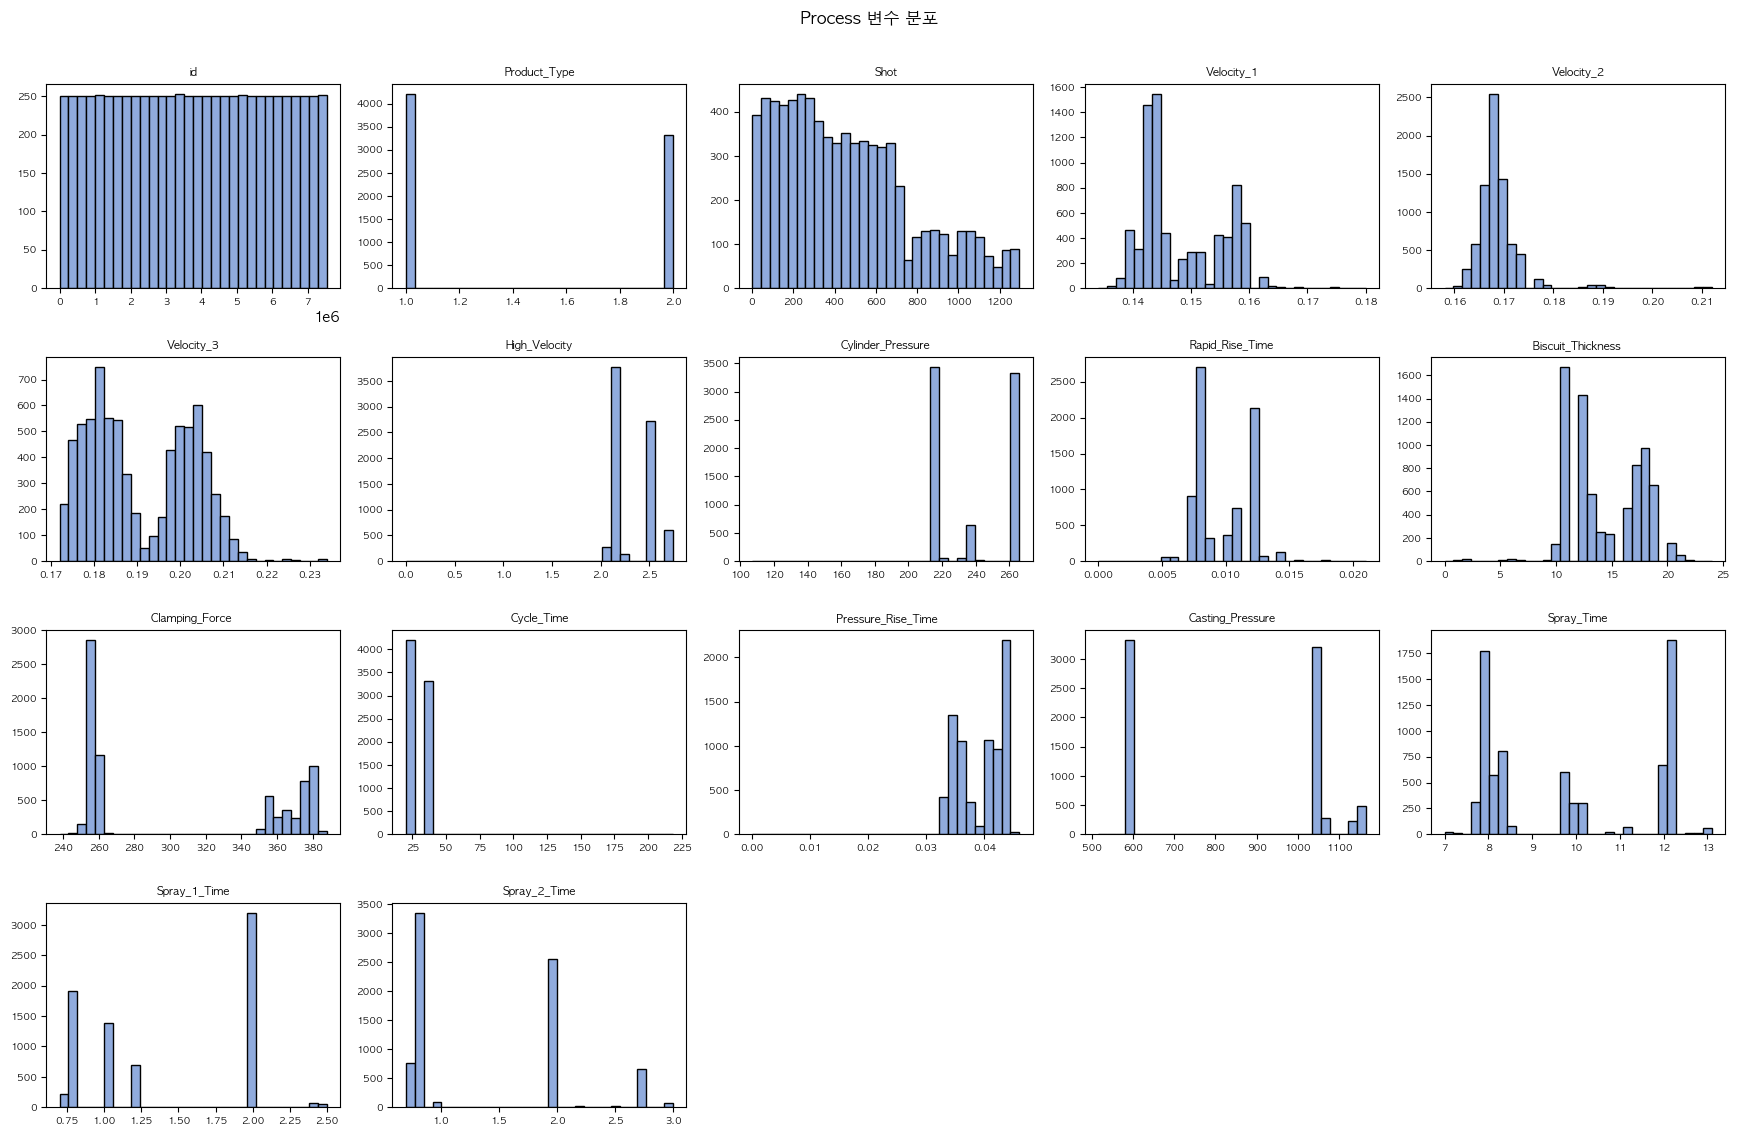

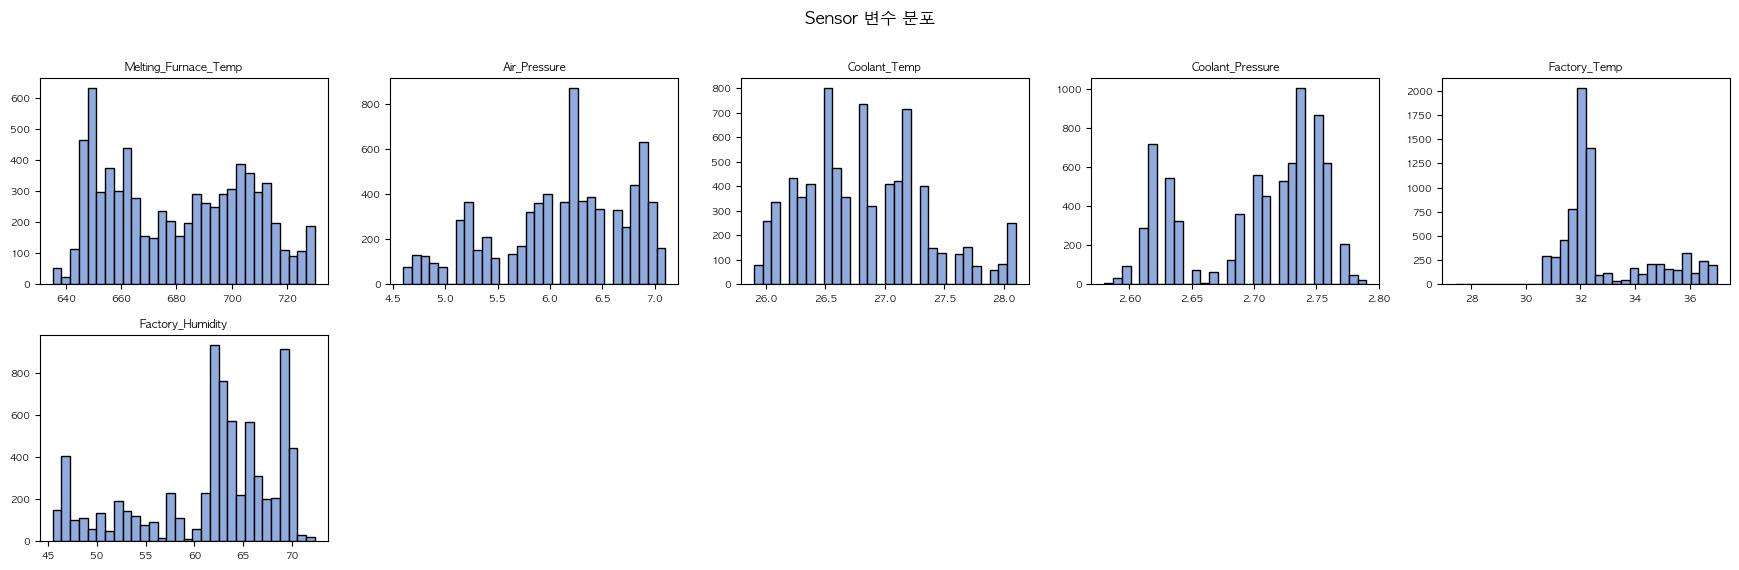

In [5]:
# ── 유틸: min/max 컬럼 제외
def is_minmax(col):
    s = str(col).strip().lower()
    return bool(re.search(r"(^|[_\s])(min|max)($|[_\s])", s)) or s in {"min","max"}

def plot_hist_group(df_grp, group_name, cols_per_row=5, bins=30):
    use_cols = [c for c in df_grp.columns if not is_minmax(c[1] if isinstance(c,tuple) else c)]
    n = len(use_cols)
    if n == 0: return
    nrows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(nrows, cols_per_row,
                             figsize=(cols_per_row*3.5, nrows*2.8))
    axes = np.array(axes).flatten()
    for ax, col in zip(axes, use_cols):
        x = pd.to_numeric(df_grp[col], errors="coerce").dropna()
        label = col[1] if isinstance(col,tuple) else str(col)
        ax.hist(x, bins=bins, edgecolor="black", lw=0.3,
                color=(144/255,171/255,221/255))
        ax.set_title(label, fontsize=8)
        ax.tick_params(labelsize=7)
    for ax in axes[n:]: ax.set_visible(False)
    fig.suptitle(f"{group_name} 변수 분포", fontsize=12, y=1.01)
    plt.tight_layout(); plt.show()

plot_hist_group(df_process, "Process")
plot_hist_group(df_sensor,  "Sensor")


### 2-2. 상관관계 히트맵 (Process vs Process / Process vs Defects / Sensor vs Defects)

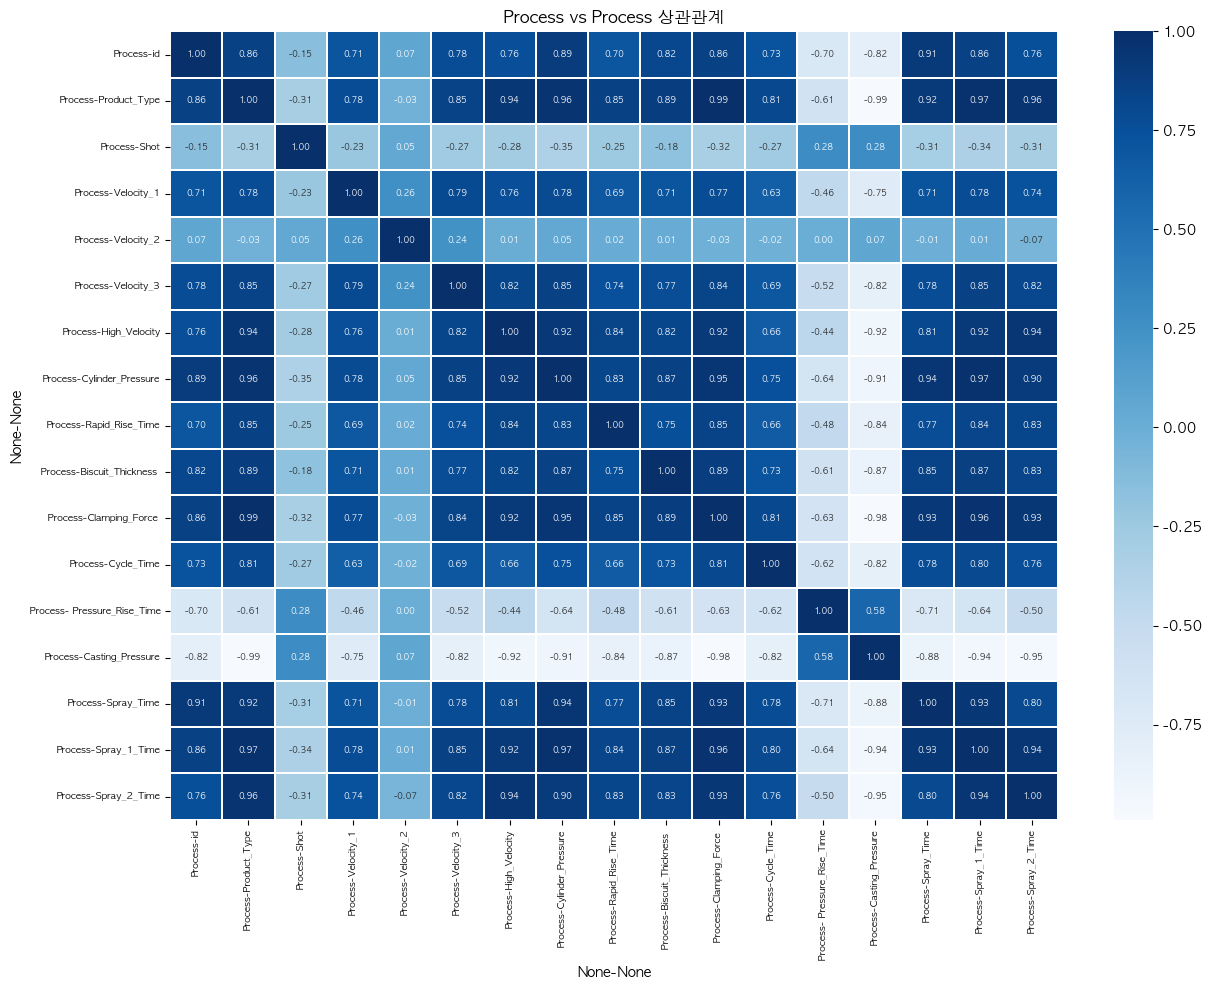

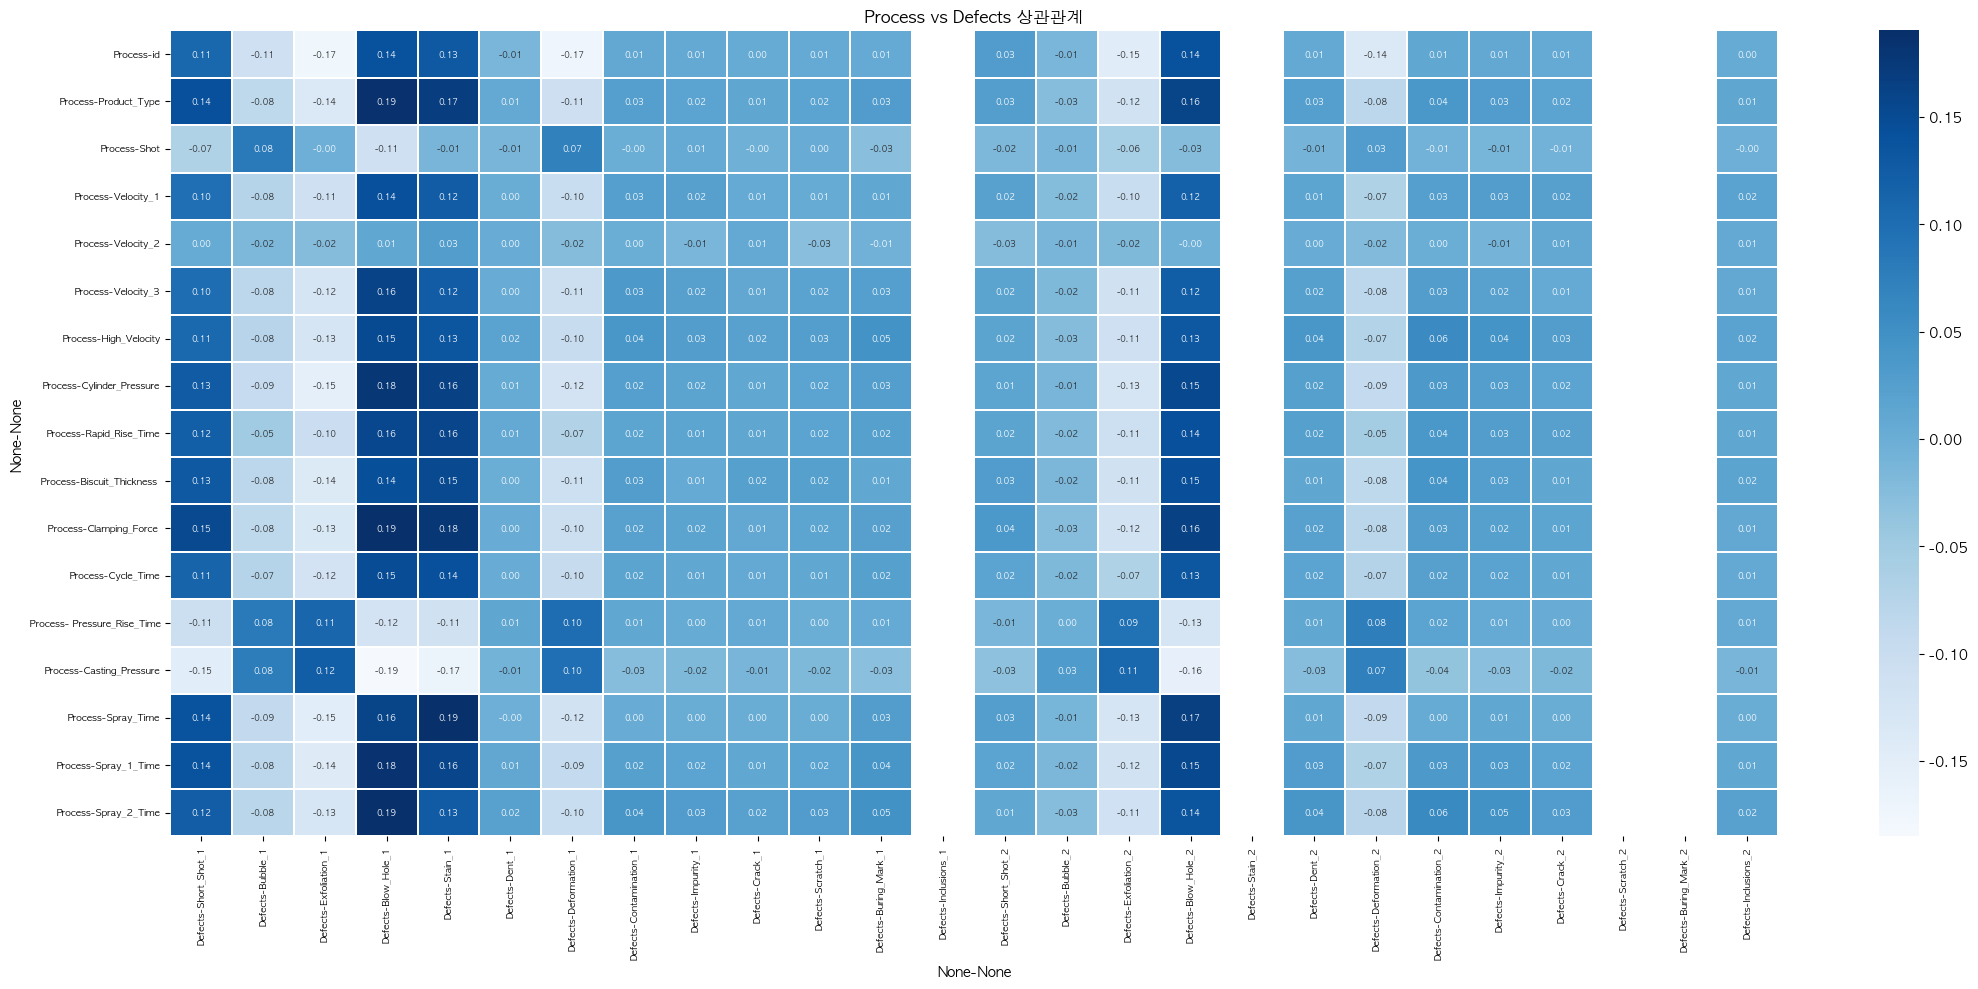

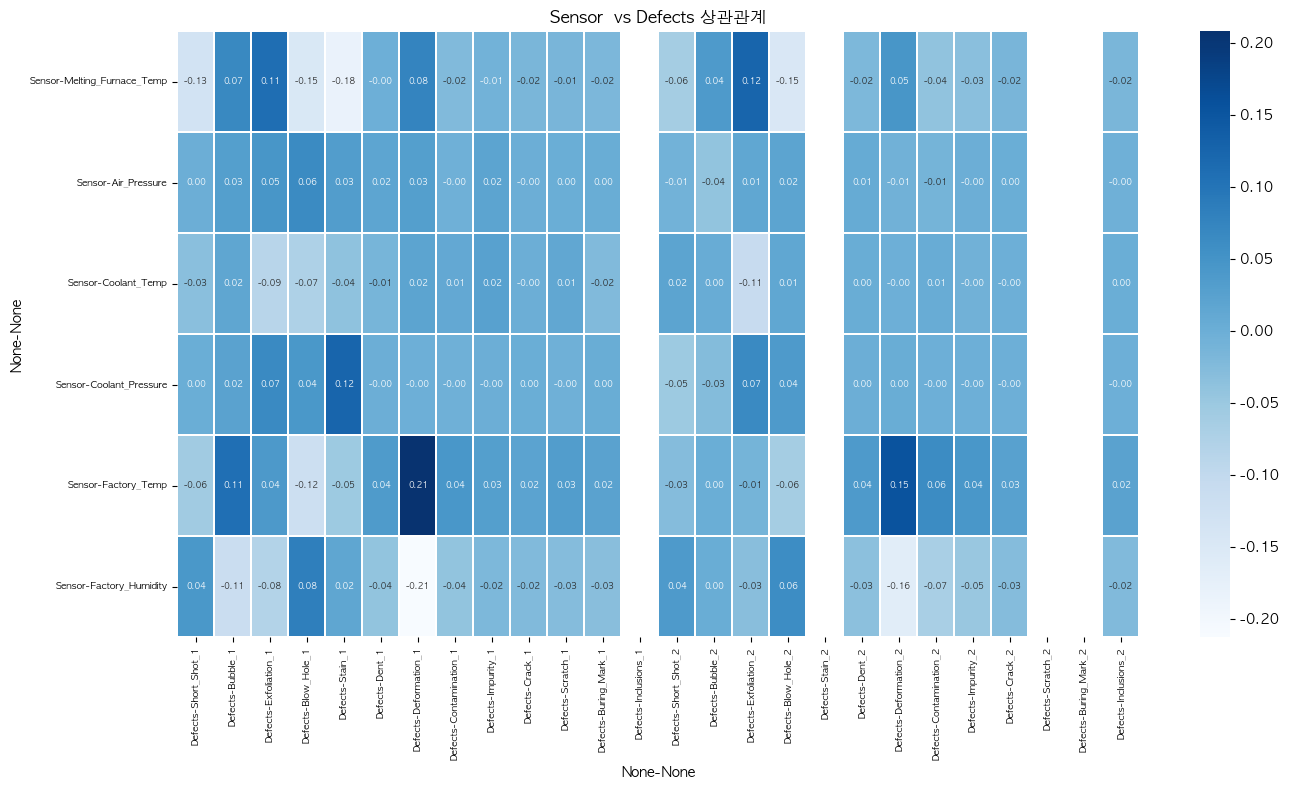


[해석] Process·Sensor 독립변수와 Defects 종속변수 간 선형 상관계수가 대부분 0.2 이하.
→ 하나의 결함에 여러 변수가 복합적으로 작용 → 비선형 모델(LGBM) + SHAP으로 영향력 파악 필요.



In [6]:
def prep_corr(df_in, fill_zero=False):
    d = df_in.apply(pd.to_numeric, errors="coerce")
    return d.fillna(0) if fill_zero else d.fillna(d.median(numeric_only=True))

pc_use = prep_corr(df_process[[c for c in df_process.columns if not is_minmax(c[1])]])
sc_use = prep_corr(df_sensor [[c for c in df_sensor.columns  if not is_minmax(c[1])]])
dc_use = prep_corr(df_defects, fill_zero=True)

corr_pp  = pc_use.corr()
corr_pd  = pd.concat([pc_use, dc_use], axis=1).corr().loc[pc_use.columns, dc_use.columns]
corr_sd  = pd.concat([sc_use, dc_use], axis=1).corr().loc[sc_use.columns, dc_use.columns]

def plot_hm(mat, title, figsize=(16,10)):
    plt.figure(figsize=figsize)
    sns.heatmap(mat, linewidths=0.1, annot=True, fmt=".2f",
                cmap="Blues", center=0, annot_kws={"size":6})
    plt.title(title, fontsize=12)
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0,  fontsize=7)
    plt.tight_layout(); plt.show()

plot_hm(corr_pp, "Process vs Process 상관관계", figsize=(13,10))
plot_hm(corr_pd, "Process vs Defects 상관관계", figsize=(22,10))
plot_hm(corr_sd, "Sensor  vs Defects 상관관계", figsize=(14,8))

print("""
[해석] Process·Sensor 독립변수와 Defects 종속변수 간 선형 상관계수가 대부분 0.2 이하.
→ 하나의 결함에 여러 변수가 복합적으로 작용 → 비선형 모델(LGBM) + SHAP으로 영향력 파악 필요.
""")


### 2-3. Z-score 이상치 분석

[Process] |z|>3.0  이상치 포함 행: 221/7535 (2.9%)  셀 총합: 279
                             outlier_count  outlier_rate
Process Velocity_2                     144        0.0191
        Biscuit_Thickness               36        0.0048
        Rapid_Rise_Time                 22        0.0029
        Velocity_1                      22        0.0029
        Velocity_3                      18        0.0024
        Cycle_Time                      15        0.0020
        High_Velocity                   14        0.0019
         Pressure_Rise_Time              4        0.0005

[Sensor] |z|>3.0  이상치 포함 행: 2/7535 (0.0%)  셀 총합: 2
                             outlier_count  outlier_rate
Sensor Factory_Temp                      2        0.0003
       Melting_Furnace_Temp              0        0.0000
       Air_Pressure                      0        0.0000
       Coolant_Temp                      0        0.0000
       Coolant_Pressure                  0        0.0000
       Factory_Humidity              

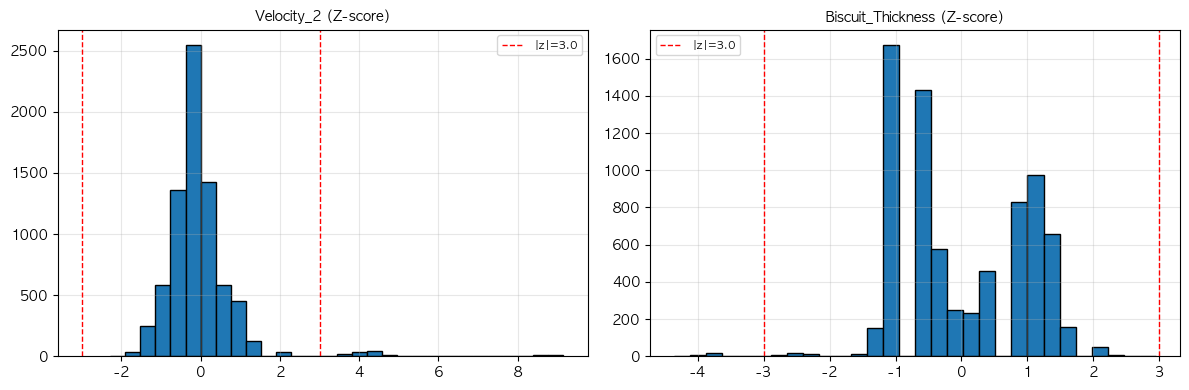


[결론] 이상치 약 200개 수준 → 제거보다 이상치에 강건한 트리 모델로 대응.



In [7]:
def zscore_df(df_in):
    d = df_in.apply(pd.to_numeric, errors="coerce")
    d = d.fillna(d.median(numeric_only=True))
    sc = StandardScaler()
    return pd.DataFrame(sc.fit_transform(d.values), columns=d.columns, index=d.index)

def outlier_summary(z_df, group_name):
    mask  = z_df.abs() > Z_THRESH
    rows  = int(mask.any(axis=1).sum())
    total = int(mask.sum().sum())
    print(f"[{group_name}] |z|>{Z_THRESH}  이상치 포함 행: {rows}/{len(z_df)} ({rows/len(z_df):.1%})  셀 총합: {total}")
    return pd.DataFrame({
        "outlier_count": mask.sum(axis=0),
        "outlier_rate" : (mask.sum(axis=0)/len(z_df)).round(4)
    }).sort_values("outlier_count", ascending=False)

z_proc = zscore_df(df_process[[c for c in df_process.columns if not is_minmax(c[1])]])
z_sens = zscore_df(df_sensor [[c for c in df_sensor.columns  if not is_minmax(c[1])]])

print(outlier_summary(z_proc,"Process").head(8).to_string())
print()
print(outlier_summary(z_sens,"Sensor").head(8).to_string())

# 대표 컬럼 시각화
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, (title, s, thresh) in zip(axes, [
        ("Velocity_2 (Z-score)", z_proc[("Process","Velocity_2")], True),
        ("Biscuit_Thickness (Z-score)", z_proc[("Process","Biscuit_Thickness ")], True)]):
    x = pd.to_numeric(s, errors="coerce").dropna()
    ax.hist(x, bins=30, edgecolor="black", lw=0.3)
    ax.axvline(+Z_THRESH, color="red", ls="--", lw=1, label=f"|z|={Z_THRESH}")
    ax.axvline(-Z_THRESH, color="red", ls="--", lw=1)
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("""
[결론] 이상치 약 200개 수준 → 제거보다 이상치에 강건한 트리 모델로 대응.
""")


### 2-4. 독립 2표본 t-검정 – 불량별 유의 공정변수 탐색

In [8]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

_exclude = {("Process","id"), ("Process","Shot"), ("Process","Product_Type")}
feat_cols = [c for c in process_cols + sensor_cols
             if c not in _exclude and not is_minmax(c[1])]

ttest_rows = []
for d_col in defect_cols:
    is_bad  = (pd.to_numeric(df[d_col], errors="coerce") > 0)
    n_good, n_bad = int((~is_bad).sum()), int(is_bad.sum())
    if n_bad < 5: continue

    sig, top5 = 0, []
    for f in feat_cols:
        v = pd.to_numeric(df[f], errors="coerce")
        g0, g1 = v[~is_bad].dropna(), v[is_bad].dropna()
        if len(g0) < 2 or len(g1) < 2: continue
        _, p = ttest_ind(g0, g1, equal_var=False)
        if p < ALPHA:
            sig += 1
            top5.append((p, f"{f[0]}_{f[1]}"))
    top5.sort(); top5 = [nm for _,nm in top5[:5]]
    ttest_rows.append({"defect": d_col[1], "n_good": n_good, "n_defect": n_bad,
                        "sig_p_cnt": sig, "top5_vars(p<alpha)": ", ".join(top5)})

ttest_df = pd.DataFrame(ttest_rows).sort_values("n_defect", ascending=False)
display(ttest_df.reset_index(drop=True))


,defect,n_good,n_defect,sig_p_cnt,top5_vars(p<alpha)
0,Short_Shot_1,7038,497,17,"Process_Casting_Pressure, Process_Clamping_Force , Sensor_Melting_Furnace_Temp, Process_Spray_1_Time, Process_Cycle_Time"
1,Blow_Hole_1,7314,221,19,"Process_Casting_Pressure, Process_Clamping_Force , Process_Cycle_Time, Process_Cylinder_Pressure, Process_High_Velocity"
2,Stain_1,7346,189,20,"Process_Casting_Pressure, Process_Cycle_Time, Process_Spray_2_Time, Process_Spray_1_Time, Process_Spray_Time"
3,Short_Shot_2,7355,180,9,"Sensor_Melting_Furnace_Temp, Sensor_Coolant_Pressure, Process_Velocity_2, Sensor_Factory_Humidity, Process_Clamping_Force"
4,Exfoliation_1,7362,173,20,"Process_Casting_Pressure, Process_Clamping_Force , Process_Cycle_Time, Process_Cylinder_Pressure, Process_High_Velocity"
5,Blow_Hole_2,7380,155,17,"Process_Casting_Pressure, Process_Cycle_Time, Process_Cylinder_Pressure, Process_High_Velocity, Process_Spray_1_Time"
6,Exfoliation_2,7404,131,19,"Process_Clamping_Force , Process_High_Velocity, Process_Spray_2_Time, Process_Casting_Pressure, Process_Spray_Time"
7,Deformation_1,7427,108,19,"Process_Casting_Pressure, Process_Clamping_Force , Process_Cycle_Time, Process_Cylinder_Pressure, Process_High_Velocity"
8,Bubble_1,7463,72,20,"Process_Spray_Time, Process_Cycle_Time, Process_Clamping_Force , Process_Cylinder_Pressure, Process_Casting_Pressure"
9,Deformation_2,7471,64,17,"Process_Casting_Pressure, Process_Clamping_Force , Process_Cycle_Time, Process_Spray_2_Time, Process_Spray_Time"


## 3. 전처리
### 3-1. Sensor 결측치 → 중앙값 대체

In [9]:
print(f"처리 전 결측치: {df[sensor_cols].isnull().sum().sum()}")
for col in sensor_cols:
    df[col] = df[col].fillna(df[col].median())
print(f"처리 후 결측치: {df[sensor_cols].isnull().sum().sum()}")


처리 전 결측치: 540
처리 후 결측치: 0


### 3-2. Defects 이진화 (0/1)

In [10]:
df[defect_cols] = (df[defect_cols] > 0).astype(int)
print("[이진화 완료] 불량 유형별 발생 건수:")
print(df[defect_cols].sum().to_string())


[이진화 완료] 불량 유형별 발생 건수:
Defects  Short_Shot_1       497
         Bubble_1            72
         Exfoliation_1      173
         Blow_Hole_1        221
         Stain_1            189
         Dent_1               7
         Deformation_1      108
         Contamination_1      4
         Impurity_1           2
         Crack_1              1
         Scratch_1            2
         Buring_Mark_1        5
         Inclusions_1         0
         Short_Shot_2       180
         Bubble_2             7
         Exfoliation_2      131
         Blow_Hole_2        155
         Stain_2              0
         Dent_2               4
         Deformation_2       64
         Contamination_2      8
         Impurity_2           5
         Crack_2              2
         Scratch_2            0
         Buring_Mark_2        0
         Inclusions_2         1


### 3-3. 불량 유형 그룹화

| 그룹 | 포함 불량 |
|---|---|
| 충전불량 | Short_Shot |
| 기포/내부 | Bubble, Blow_Hole |
| 표면손상 | Dent, Scratch, Stain, Buring_Mark, Exfoliation |
| 기타 | Crack, Deformation, Impurity, Contamination, Inclusions |

[불량 유형별 건수]
  충전불량      :  670건 / 7535행 (8.9%)
  기포/내부     :  442건 / 7535행 (5.9%)
  표면손상      :  500건 / 7535행 (6.6%)
  기타        :  191건 / 7535행 (2.5%)


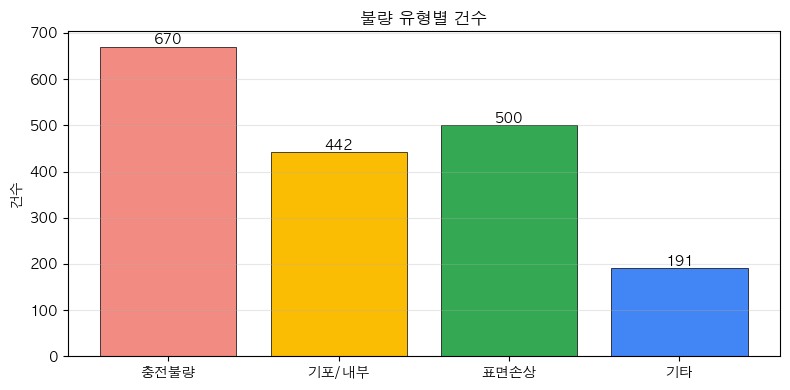

In [11]:
group_defect = {
    "충전불량": [("Defects","Short_Shot_1"),("Defects","Short_Shot_2")],
    "기포/내부": [("Defects","Bubble_1"),("Defects","Blow_Hole_1"),
                   ("Defects","Bubble_2"),("Defects","Blow_Hole_2")],
    "표면손상": [("Defects","Dent_1"),("Defects","Scratch_1"),("Defects","Stain_1"),
                  ("Defects","Buring_Mark_1"),("Defects","Exfoliation_1"),
                  ("Defects","Dent_2"),("Defects","Scratch_2"),("Defects","Stain_2"),
                  ("Defects","Buring_Mark_2"),("Defects","Exfoliation_2")],
    "기타": [("Defects","Crack_1"),("Defects","Deformation_1"),
              ("Defects","Impurity_1"),("Defects","Contamination_1"),("Defects","Inclusions_1"),
              ("Defects","Crack_2"),("Defects","Deformation_2"),
              ("Defects","Impurity_2"),("Defects","Contamination_2"),("Defects","Inclusions_2")]
}

# Cavity 중 하나라도 불량이면 불량
Y_group = pd.DataFrame(index=df.index)
for gname, cols in group_defect.items():
    exist = [c for c in cols if c in df.columns]
    Y_group[gname] = df[exist].max(axis=1).astype(int)

# Product_Type 통합 (불균형 심해 합산)
print("[불량 유형별 건수]")
for g in Y_group.columns:
    cnt = int(Y_group[g].sum())
    print(f"  {g:<10}: {cnt:>4}건 / {len(Y_group)}행 ({cnt/len(Y_group):.1%})")

# 불량 분포 시각화
fig, ax = plt.subplots(figsize=(8,4))
cnts = Y_group.sum()
bars = ax.bar(cnts.index, cnts.values,
              color=["#f28b82","#fbbc04","#34a853","#4285f4"],
              edgecolor="black", lw=0.5)
for bar, v in zip(bars, cnts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+5, str(v), ha="center", fontsize=10)
ax.set_title("불량 유형별 건수", fontsize=12)
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


### 3-4. Feature 행렬 생성

In [12]:
drop_cols = [("Process","id"), ("Process","Shot"), ("Process","Product_Type")]
X_all = df[process_cols + sensor_cols].copy()
X_all = X_all.drop(columns=[c for c in drop_cols if c in X_all.columns])

# 상수 컬럼 제거
const = X_all.columns[X_all.nunique() <= 1]
X_all = X_all.drop(columns=const)

# MultiIndex → 문자열
X = X_all.copy()
X.columns = [f"{a}|{b}" for a, b in X.columns]
print(f"Feature 수: {X.shape[1]}")
print(X.columns.tolist())


Feature 수: 20
['Process|Velocity_1', 'Process|Velocity_2', 'Process|Velocity_3', 'Process|High_Velocity', 'Process|Cylinder_Pressure', 'Process|Rapid_Rise_Time', 'Process|Biscuit_Thickness ', 'Process|Clamping_Force ', 'Process|Cycle_Time', 'Process| Pressure_Rise_Time', 'Process|Casting_Pressure', 'Process|Spray_Time', 'Process|Spray_1_Time', 'Process|Spray_2_Time', 'Sensor|Melting_Furnace_Temp', 'Sensor|Air_Pressure', 'Sensor|Coolant_Temp', 'Sensor|Coolant_Pressure', 'Sensor|Factory_Temp', 'Sensor|Factory_Humidity']


### 3-5. SMOTE (기타 그룹 – 1:1 오버샘플링)

In [13]:
def apply_smote(gname, X_tr, y_tr):
    """기타 그룹만 SMOTE 적용 (소수 클래스가 2개 이상일 때)"""
    if gname != "기타": return X_tr, y_tr
    vc = y_tr.value_counts()
    if len(vc) < 2 or int(vc.min()) < 2: return X_tr, y_tr
    k = min(5, int(vc.min()) - 1)
    return SMOTE(random_state=RANDOM_STATE, k_neighbors=k).fit_resample(X_tr, y_tr)

# 확인
y_ex = Y_group["기타"]
Xtr, Xte, ytr, yte = train_test_split(X, y_ex, test_size=TEST_SIZE,
                                       random_state=RANDOM_STATE, stratify=y_ex)
Xtr_sm, ytr_sm = apply_smote("기타", Xtr, ytr)
print(f"기타 – SMOTE 전: {dict(ytr.value_counts())}")
print(f"기타 – SMOTE 후: {dict(pd.Series(ytr_sm).value_counts())}")


기타 – SMOTE 전: {0: np.int64(5875), 1: np.int64(153)}
기타 – SMOTE 후: {0: np.int64(5875), 1: np.int64(5875)}


## 4. 모델링

> **KPI**: Recall ≥ 70%, Precision ≥ 20%  
> 전략: PR-AUC 기준 최적 모델 선정 → Threshold 0.68 탐색

### 4-1. PR Curve & ROC Curve (모델 선정 근거)

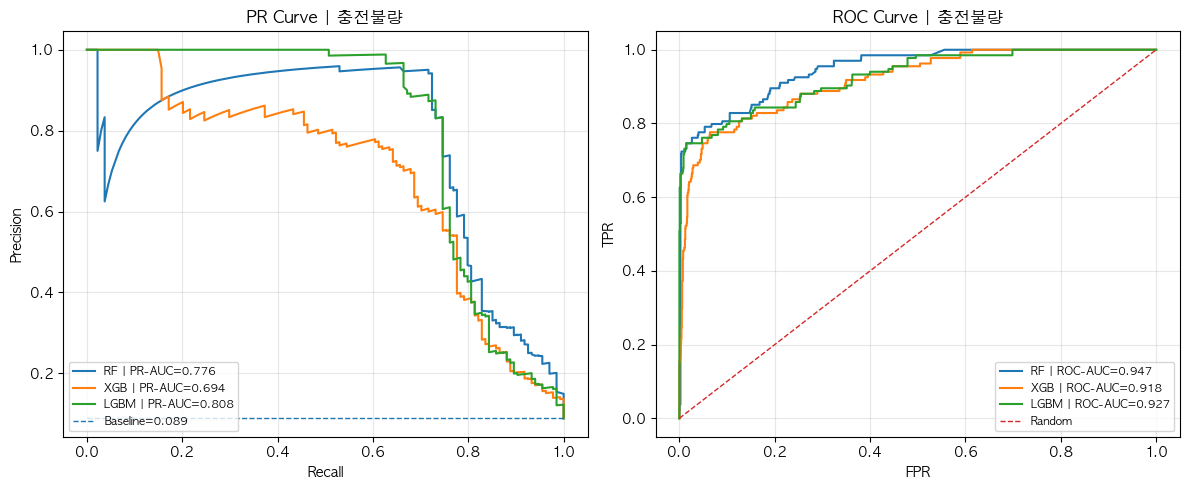

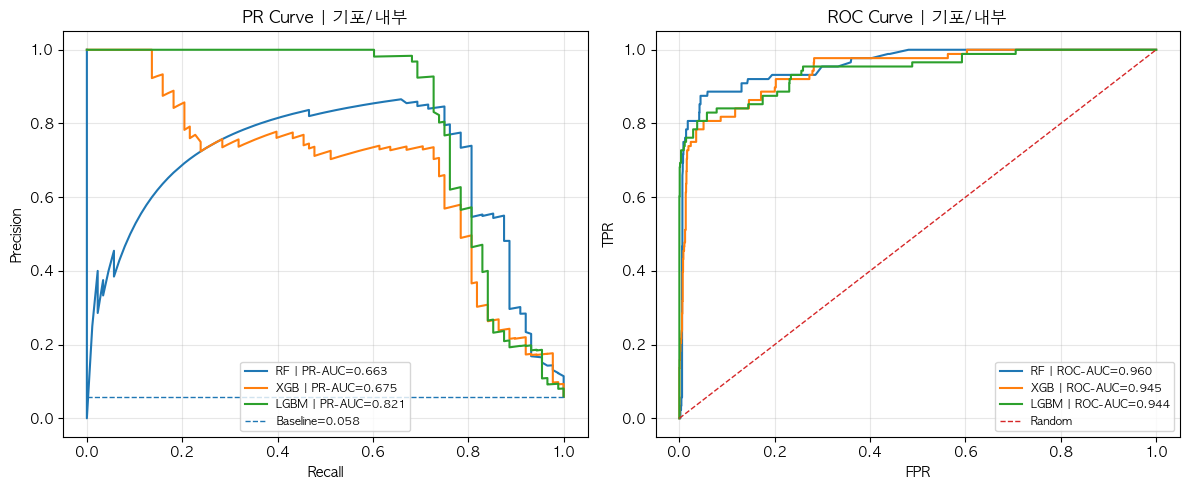

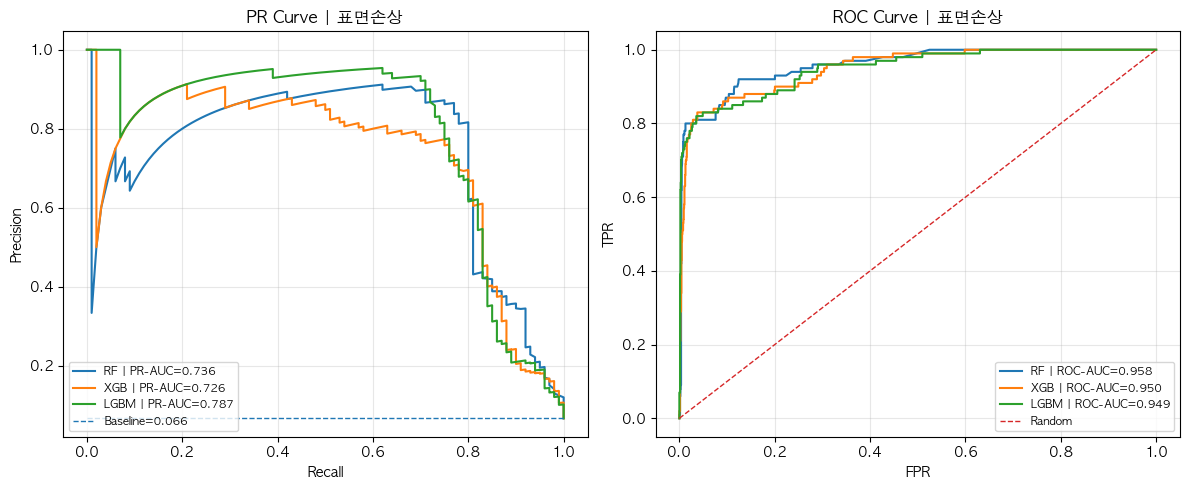

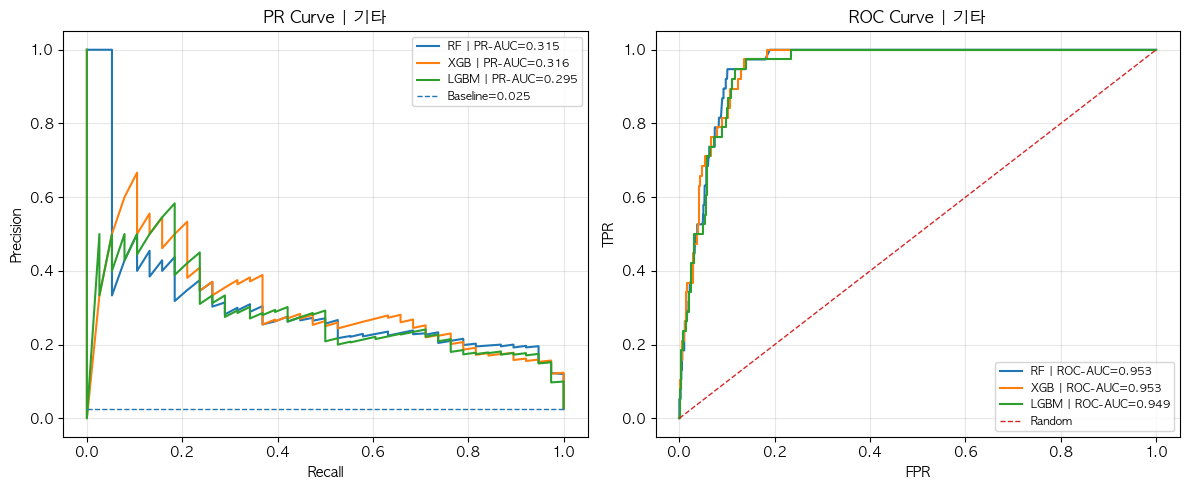

PR_AUC                      ROC_AUC                     
group     기타  기포/내부   충전불량   표면손상      기타  기포/내부   충전불량   표면손상
model                                                         
LGBM   0.295  0.821  0.808  0.787   0.949  0.944  0.927  0.949
RF     0.315  0.663  0.776  0.736   0.953  0.960  0.947  0.958
XGB    0.316  0.675  0.694  0.726   0.953  0.945  0.918  0.950


[선정 근거] 전 그룹에서 LGBM PR-AUC 최고 또는 동등 → LightGBM 최종 선택


In [14]:
pr_roc_rows = []

for gname in Y_group.columns:
    y = Y_group[gname]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE,
                                            random_state=RANDOM_STATE, stratify=y)
    Xtr, ytr = apply_smote(gname, Xtr, ytr)
    pos = int((ytr==1).sum()); neg = int((ytr==0).sum())
    spw = neg/pos if pos>0 else 1

    mdls = {
        "RF"  : RandomForestClassifier(n_estimators=300,random_state=RANDOM_STATE,
                                        n_jobs=-1,class_weight="balanced"),
        "XGB" : XGBClassifier(n_estimators=400,learning_rate=0.05,max_depth=5,
                               subsample=0.9,colsample_bytree=0.9,
                               random_state=RANDOM_STATE,n_jobs=-1,
                               eval_metric="logloss",scale_pos_weight=spw),
        "LGBM": LGBMClassifier(n_estimators=600,learning_rate=0.05,max_depth=-1,
                                num_leaves=31,subsample=0.9,colsample_bytree=0.9,
                                random_state=RANDOM_STATE,n_jobs=-1,verbosity=-1)
    }

    fig, (ax_pr, ax_roc) = plt.subplots(1,2,figsize=(12,5))
    for mname, mdl in mdls.items():
        mdl.fit(Xtr, ytr)
        prob = mdl.predict_proba(Xte)[:,1]

        p_arr, r_arr, _ = precision_recall_curve(yte, prob)
        pr_auc = average_precision_score(yte, prob)
        fpr, tpr, _ = roc_curve(yte, prob)
        roc_auc = roc_auc_score(yte, prob)

        ax_pr.plot(r_arr, p_arr, label=f"{mname} | PR-AUC={pr_auc:.3f}")
        ax_roc.plot(fpr, tpr, label=f"{mname} | ROC-AUC={roc_auc:.3f}")
        pr_roc_rows.append({"group":gname,"model":mname,"PR_AUC":pr_auc,"ROC_AUC":roc_auc})

    base = yte.sum()/len(yte)
    ax_pr.hlines(base,0,1,ls="dashed",lw=1,label=f"Baseline={base:.3f}")
    ax_pr.set_title(f"PR Curve | {gname}"); ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
    ax_pr.legend(fontsize=8); ax_pr.grid(alpha=0.3)

    ax_roc.plot([0,1],[0,1],ls="dashed",lw=1,label="Random")
    ax_roc.set_title(f"ROC Curve | {gname}"); ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
    ax_roc.legend(fontsize=8); ax_roc.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

pr_pivot = pd.DataFrame(pr_roc_rows).pivot_table(
    index="model", columns="group", values=["PR_AUC","ROC_AUC"], aggfunc="mean").round(3)
display(pr_pivot)
print("\n[선정 근거] 전 그룹에서 LGBM PR-AUC 최고 또는 동등 → LightGBM 최종 선택")


### 4-2. Threshold 탐색 곡선 (LightGBM)

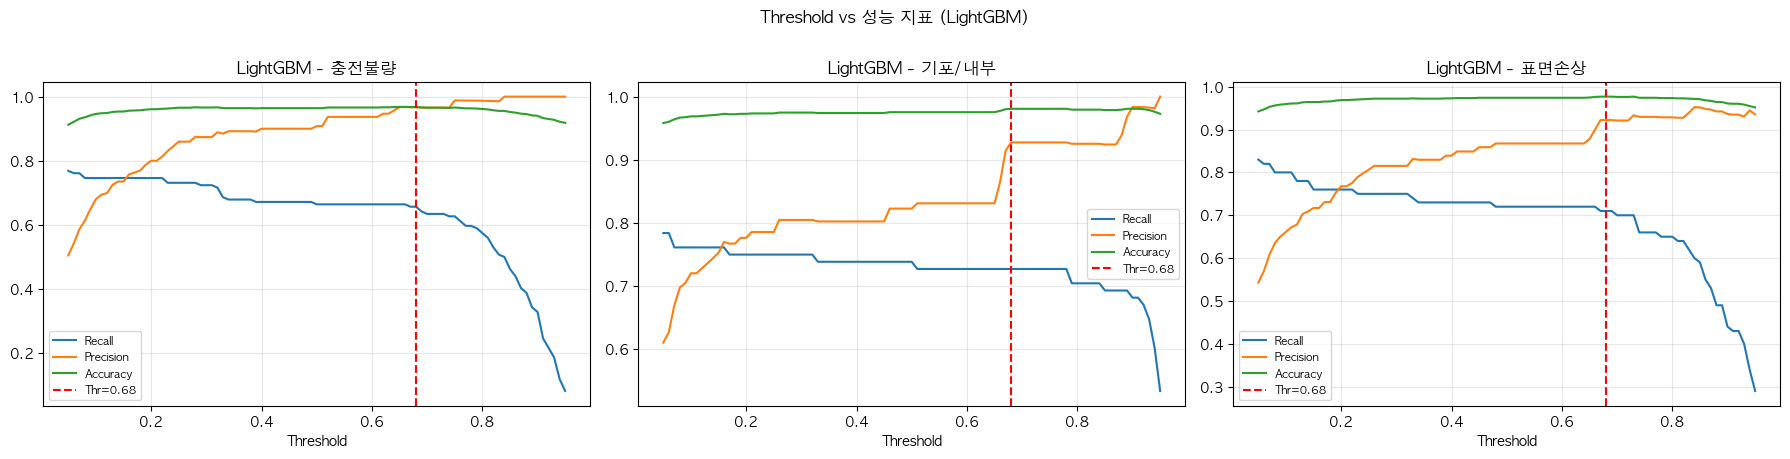

[선택] Threshold = 0.68  (PR 변곡점 0.6~0.8 탐색 결과)


In [15]:
thresholds = np.round(np.arange(0.05,0.96,0.01),2)
sweep_rows = []

plot_groups = [g for g in Y_group.columns if g != "기타"]
for gname in plot_groups:
    y = Y_group[gname]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE,
                                            random_state=RANDOM_STATE, stratify=y)
    Xtr, ytr = apply_smote(gname, Xtr, ytr)
    mdl = LGBMClassifier(n_estimators=600,learning_rate=0.05,num_leaves=31,
                          subsample=0.9,colsample_bytree=0.9,
                          random_state=RANDOM_STATE,n_jobs=-1,verbosity=-1)
    mdl.fit(Xtr, ytr); prob = mdl.predict_proba(Xte)[:,1]
    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        sweep_rows.append({"group":gname,"threshold":thr,
                            "recall":recall_score(yte,pred,zero_division=0),
                            "precision":precision_score(yte,pred,zero_division=0),
                            "accuracy":accuracy_score(yte,pred)})

sweep_df = pd.DataFrame(sweep_rows)
fig, axes = plt.subplots(1,len(plot_groups),figsize=(6*len(plot_groups),4.5))
if len(plot_groups)==1: axes=[axes]
for ax, g in zip(axes, plot_groups):
    sub = sweep_df[sweep_df["group"]==g].sort_values("threshold")
    ax.plot(sub["threshold"],sub["recall"],    label="Recall")
    ax.plot(sub["threshold"],sub["precision"], label="Precision")
    ax.plot(sub["threshold"],sub["accuracy"],  label="Accuracy")
    ax.axvline(THRESHOLD,color="red",ls="--",lw=1.5,label=f"Thr={THRESHOLD}")
    ax.set_title(f"LightGBM - {g}"); ax.set_xlabel("Threshold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Threshold vs 성능 지표 (LightGBM)", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()
print(f"[선택] Threshold = {THRESHOLD}  (PR 변곡점 0.6~0.8 탐색 결과)")


### 4-3. 최종 모델 학습 & 평가 (RF / XGB / LGBM)

In [16]:
rf_results   = {}
xgb_results  = {}
lgbm_results = {}

def run_model(mdl, Xtr, Xte, ytr, yte):
    mdl.fit(Xtr, ytr)
    prob = mdl.predict_proba(Xte)[:,1]
    pred = (prob >= THRESHOLD).astype(int)
    return {
        "accuracy" : accuracy_score(yte, pred),
        "precision": precision_score(yte, pred, zero_division=0),
        "recall"   : recall_score(yte, pred, zero_division=0),
        "f1"       : f1_score(yte, pred, zero_division=0),
        "cm"       : confusion_matrix(yte, pred),
        "model"    : mdl,
        "top10"    : pd.Series(mdl.feature_importances_, index=X.columns)
                       .sort_values(ascending=False).head(10),
        "X_test"   : Xte,
        "y_test"   : yte,
    }

for gname in Y_group.columns:
    y = Y_group[gname]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE,
                                            random_state=RANDOM_STATE, stratify=y)
    Xtr_sm, ytr_sm = apply_smote(gname, Xtr, ytr)
    pos = int((ytr_sm==1).sum()); neg = int((ytr_sm==0).sum())
    spw = neg/pos if pos>0 else 1

    print(f"\n{'='*55}")
    print(f"[{gname}]  불량={int(y.sum())}건  threshold={THRESHOLD}")

    rf   = RandomForestClassifier(n_estimators=200,random_state=RANDOM_STATE,
                                   n_jobs=-1,class_weight="balanced")
    xgb  = XGBClassifier(n_estimators=400,learning_rate=0.05,max_depth=5,
                          subsample=0.9,colsample_bytree=0.9,
                          random_state=RANDOM_STATE,n_jobs=-1,
                          eval_metric="logloss",scale_pos_weight=spw)
    lgbm = LGBMClassifier(n_estimators=600,learning_rate=0.05,max_depth=-1,
                           num_leaves=31,subsample=0.9,colsample_bytree=0.9,
                           random_state=RANDOM_STATE,n_jobs=-1,verbosity=-1)

    rf_results[gname]   = run_model(rf,   Xtr_sm, Xte, ytr_sm, yte)
    xgb_results[gname]  = run_model(xgb,  Xtr_sm, Xte, ytr_sm, yte)
    lgbm_results[gname] = run_model(lgbm, Xtr_sm, Xte, ytr_sm, yte)

    for mname, res in [("RandomForest",rf_results[gname]),
                        ("XGBoost",    xgb_results[gname]),
                        ("LightGBM",   lgbm_results[gname])]:
        print(f"  [{mname}]  Acc={res['accuracy']:.4f}  "
              f"Pre={res['precision']:.4f}  Rec={res['recall']:.4f}  F1={res['f1']:.4f}")
        cm = res["cm"]
        print(f"            TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")



[충전불량]  불량=670건  threshold=0.68
  [RandomForest]  Acc=0.9456  Pre=0.9483  Rec=0.4104  F1=0.5729
            TN=1370 FP=3 FN=79 TP=55
  [XGBoost]  Acc=0.9456  Pre=0.7131  Rec=0.6493  F1=0.6797
            TN=1338 FP=35 FN=47 TP=87
  [LightGBM]  Acc=0.9675  Pre=0.9670  Rec=0.6567  F1=0.7822
            TN=1370 FP=3 FN=46 TP=88

[기포/내부]  불량=442건  threshold=0.68
  [RandomForest]  Acc=0.9608  Pre=0.8222  Rec=0.4205  F1=0.5564
            TN=1411 FP=8 FN=51 TP=37
  [XGBoost]  Acc=0.9602  Pre=0.6346  Rec=0.7500  F1=0.6875
            TN=1381 FP=38 FN=22 TP=66
  [LightGBM]  Acc=0.9808  Pre=0.9275  Rec=0.7273  F1=0.8153
            TN=1414 FP=5 FN=24 TP=64

[표면손상]  불량=500건  threshold=0.68
  [RandomForest]  Acc=0.9608  Pre=0.8868  Rec=0.4700  F1=0.6144
            TN=1401 FP=6 FN=53 TP=47
  [XGBoost]  Acc=0.9622  Pre=0.6838  Rec=0.8000  F1=0.7373
            TN=1370 FP=37 FN=20 TP=80
  [LightGBM]  Acc=0.9768  Pre=0.9221  Rec=0.7100  F1=0.8023
            TN=1401 FP=6 FN=29 TP=71

[기타]  불량=191건 

### 4-4. 성능 요약 테이블 & F1-Score 비교

model        LightGBM                           RandomForest          \
             accuracy      f1 precision  recall     accuracy      f1   
defect_group                                                           
기타             0.9728  0.2545    0.4118  0.1842       0.9735  0.2308   
기포/내부          0.9808  0.8153    0.9275  0.7273       0.9608  0.5564   
충전불량           0.9675  0.7822    0.9670  0.6567       0.9456  0.5729   
표면손상           0.9768  0.8023    0.9221  0.7100       0.9608  0.6144   

model                           XGBoost                            
             precision  recall accuracy      f1 precision  recall  
defect_group                                                       
기타              0.4286  0.1579   0.9748  0.2083    0.5000  0.1316  
기포/내부           0.8222  0.4205   0.9602  0.6875    0.6346  0.7500  
충전불량            0.9483  0.4104   0.9456  0.6797    0.7131  0.6493  
표면손상            0.8868  0.4700   0.9622  0.7373    0.6838  0.8000

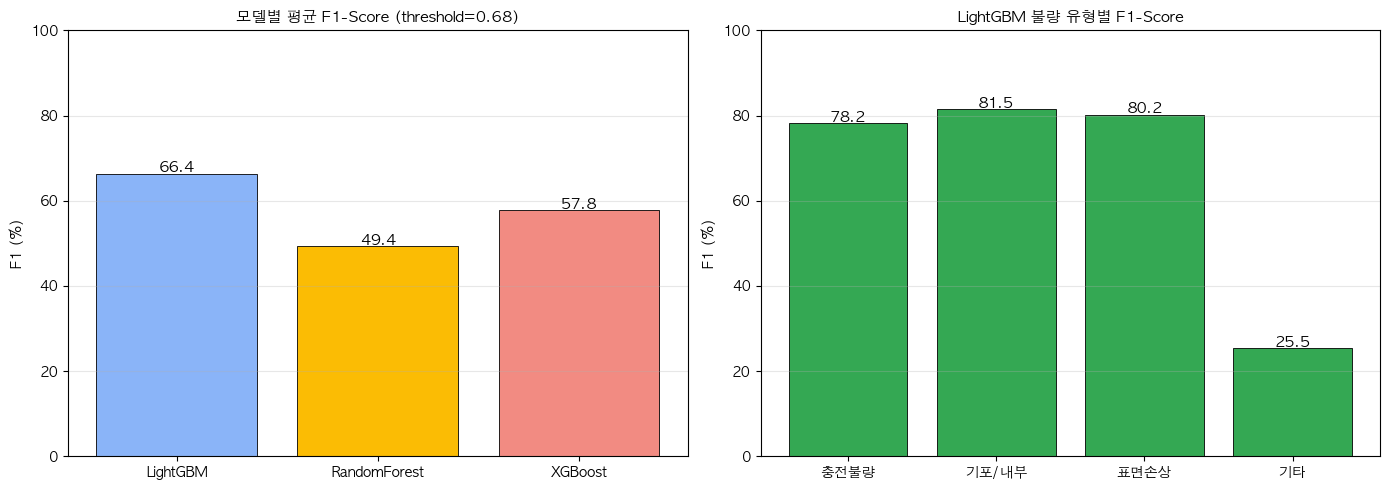

[결론] LightGBM 평균 F1 = 66.4 → 최고 성능


In [17]:
metric_cols = ["accuracy","precision","recall","f1"]
summary_rows = []
for mname, rdict in [("RandomForest",rf_results),("XGBoost",xgb_results),("LightGBM",lgbm_results)]:
    for gname, d in rdict.items():
        row = {"model":mname,"defect_group":gname}
        for m in metric_cols: row[m] = round(d[m],4)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
pivot = (summary_df
         .pivot_table(index="defect_group",columns="model",values=metric_cols,aggfunc="first")
         .swaplevel(0,1,axis=1).sort_index(axis=1,level=0))
display(pivot.round(4))

# F1 막대 비교
fig, axes = plt.subplots(1,2,figsize=(14,5))

# 모델별 평균 F1
f1_avg = summary_df.groupby("model")["f1"].mean()
colors = ["#8ab4f8","#fbbc04","#f28b82"]
axes[0].bar(f1_avg.index, f1_avg.values*100, color=colors, edgecolor="black", lw=0.6)
for i,v in enumerate(f1_avg.values):
    axes[0].text(i, v*100+0.3, f"{v*100:.1f}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("모델별 평균 F1-Score (threshold=0.68)", fontsize=11)
axes[0].set_ylabel("F1 (%)"); axes[0].grid(axis="y",alpha=0.3); axes[0].set_ylim(0,100)

# 그룹별 LightGBM F1
lgbm_f1 = {g: lgbm_results[g]["f1"] for g in Y_group.columns}
axes[1].bar(lgbm_f1.keys(), [v*100 for v in lgbm_f1.values()],
            color="#34a853", edgecolor="black", lw=0.6)
for i,(g,v) in enumerate(lgbm_f1.items()):
    axes[1].text(i, v*100+0.3, f"{v*100:.1f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("LightGBM 불량 유형별 F1-Score", fontsize=11)
axes[1].set_ylabel("F1 (%)"); axes[1].grid(axis="y",alpha=0.3); axes[1].set_ylim(0,100)

plt.tight_layout(); plt.show()
print(f"[결론] LightGBM 평균 F1 = {f1_avg['LightGBM']*100:.1f} → 최고 성능")


### 4-5. 혼동행렬 시각화 (LightGBM)

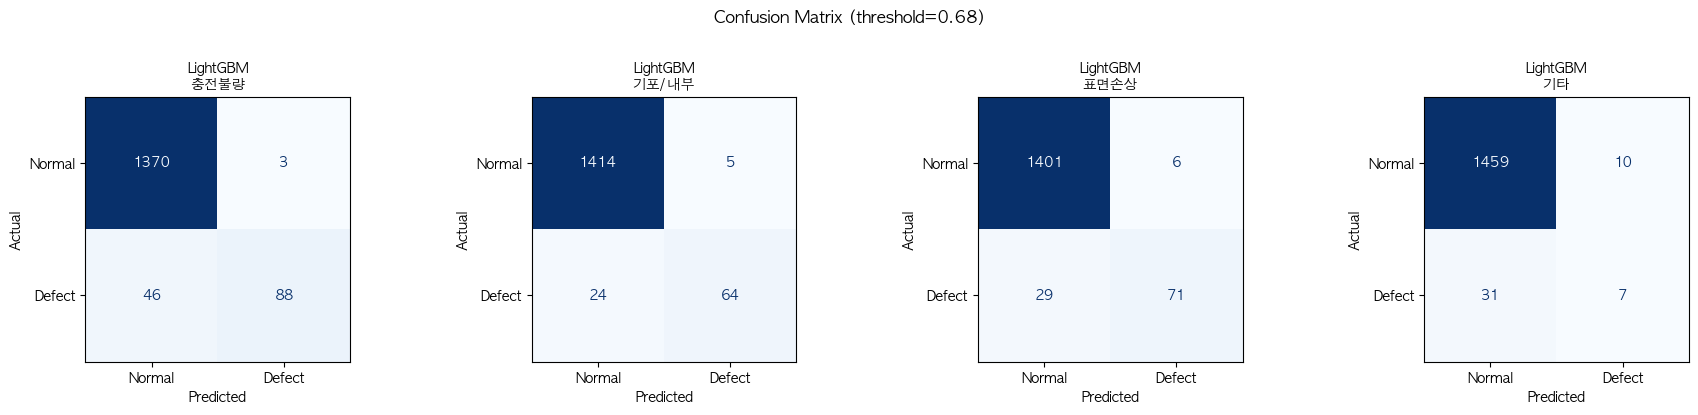

In [18]:
# (추가) 혼동행렬을 히트맵으로 시각화 → 숫자만 보는 것보다 직관적
fig, axes = plt.subplots(1, len(Y_group.columns), figsize=(4.5*len(Y_group.columns), 4))
for ax, gname in zip(axes, Y_group.columns):
    cm = lgbm_results[gname]["cm"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Normal","Defect"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"LightGBM\n{gname}", fontsize=10)
    # 라벨 영문 강제 (한글 폰트 없는 환경 대비)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrix (threshold=0.68)", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


### 4-6. 5-Fold 교차 검증 – 모델 안정성 확인 (추가)

In [19]:
# (추가) 단일 train/test split의 분산 문제를 보완
# StratifiedKFold로 불량 비율을 유지하면서 5겹 교차 검증
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_rows = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for gname in Y_group.columns:
    y = Y_group[gname]
    lgbm_cv = LGBMClassifier(n_estimators=300,learning_rate=0.05,num_leaves=31,
                              subsample=0.9,colsample_bytree=0.9,
                              random_state=RANDOM_STATE,n_jobs=-1,verbosity=-1)
    # 교차 검증은 SMOTE 미적용 버전으로 (파이프라인 간소화)
    scores = cross_val_score(lgbm_cv, X, y, cv=skf, scoring="f1", n_jobs=-1)
    cv_rows.append({"defect_group":gname,
                    "cv_f1_mean":round(scores.mean(),4),
                    "cv_f1_std" :round(scores.std(), 4),
                    "scores"    :np.round(scores,4).tolist()})
    print(f"[{gname}]  CV F1: {scores.mean():.4f} ± {scores.std():.4f}  {np.round(scores,4).tolist()}")

cv_df = pd.DataFrame(cv_rows)[["defect_group","cv_f1_mean","cv_f1_std"]]
display(cv_df)
print("\n[해석] std가 낮을수록 모델이 안정적. 기타 그룹은 데이터 희소로 분산이 큼.")


[충전불량]  CV F1: 0.6672 ± 0.0208  [0.6606, 0.6964, 0.6337, 0.6787, 0.6667]
[기포/내부]  CV F1: 0.7599 ± 0.0375  [0.6923, 0.7582, 0.7949, 0.7595, 0.7949]
[표면손상]  CV F1: 0.6476 ± 0.0555  [0.638, 0.5503, 0.6946, 0.6474, 0.7079]
[기타]  CV F1: 0.2561 ± 0.0725  [0.3214, 0.1724, 0.1739, 0.3462, 0.2667]


,defect_group,cv_f1_mean,cv_f1_std
0,충전불량,0.6672,0.0208
1,기포/내부,0.7599,0.0375
2,표면손상,0.6476,0.0555
3,기타,0.2561,0.0725



[해석] std가 낮을수록 모델이 안정적. 기타 그룹은 데이터 희소로 분산이 큼.


## 5. SHAP 해석 (LightGBM)

글로벌 주요 변수: `High_Velocity` · `Clamping_Force` · `Melting_Furnace_Temp` · `Spray_2_Time` · `Casting_Pressure`

[SHAP] 충전불량 - 변수 중요도 (mean |SHAP|)


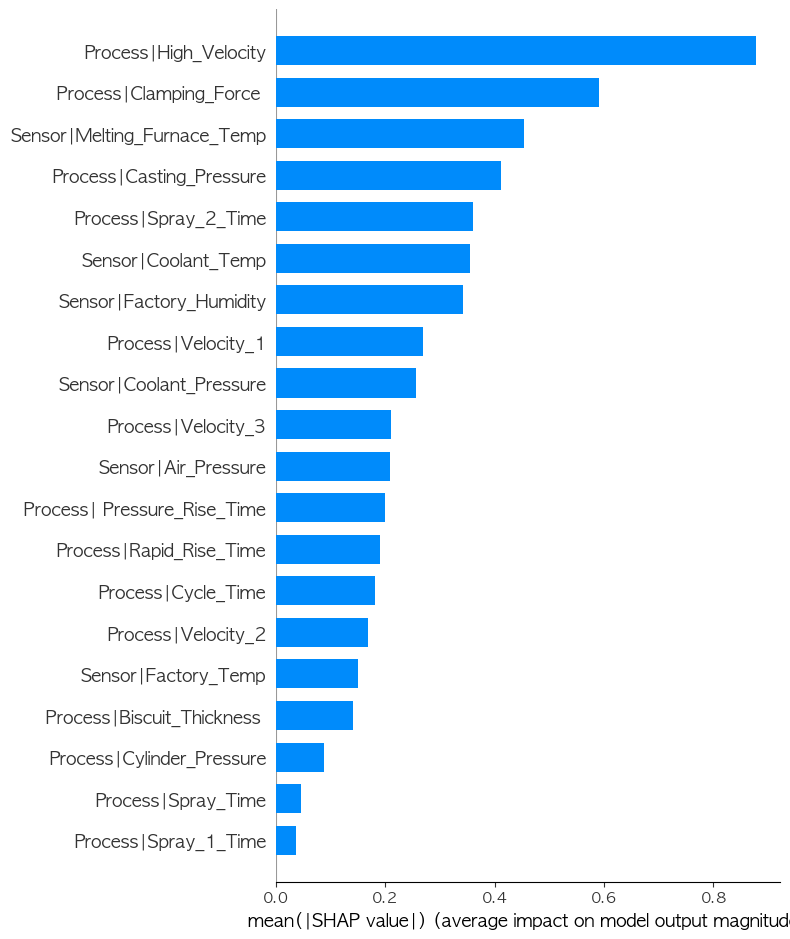

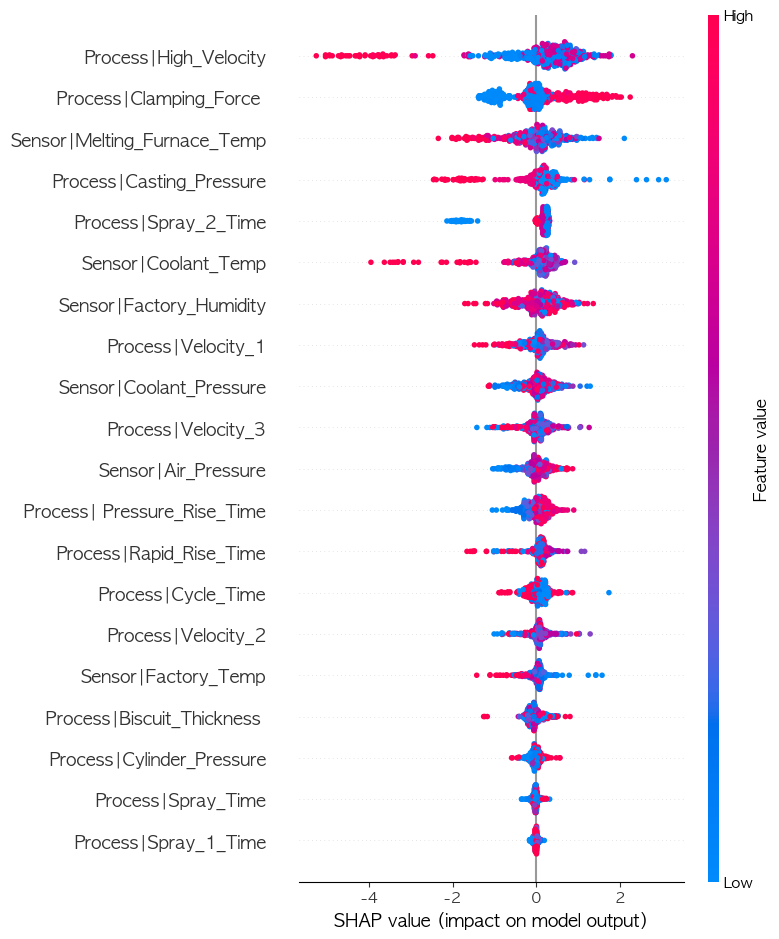


[Top 15 – 충전불량]


,feature,mean_abs_shap
0,Process|High_Velocity,0.877759
1,Process|Clamping_Force,0.590866
2,Sensor|Melting_Furnace_Temp,0.453158
3,Process|Casting_Pressure,0.412433
4,Process|Spray_2_Time,0.360722
5,Sensor|Coolant_Temp,0.354695
6,Sensor|Factory_Humidity,0.342423
7,Process|Velocity_1,0.269227
8,Sensor|Coolant_Pressure,0.255991
9,Process|Velocity_3,0.211297


In [20]:
TARGET_GROUP = "충전불량"   # 분석 대상: "충전불량" / "기포/내부" / "표면손상" / "기타"
SHAP_SAMPLE  = 500          # 속도용 서브샘플 수

mdl_shap = lgbm_results[TARGET_GROUP]["model"]
Xte_shap = lgbm_results[TARGET_GROUP]["X_test"]
yte_shap = lgbm_results[TARGET_GROUP]["y_test"]

Xexp = Xte_shap.sample(n=min(SHAP_SAMPLE,len(Xte_shap)), random_state=RANDOM_STATE)

explainer   = shap.TreeExplainer(mdl_shap)
shap_values = explainer.shap_values(Xexp)

# 반환 형태 정규화 (binary: [class0, class1])
def _get_sv(sv):
    if isinstance(sv, list):
        sv = sv[1] if len(sv)>1 else sv[0]
    if hasattr(sv,"values"): sv = sv.values
    if sv.ndim == 3: sv = sv[:,:,-1]
    return sv

sv = _get_sv(shap_values)

# ── Global Bar
print(f"[SHAP] {TARGET_GROUP} - 변수 중요도 (mean |SHAP|)")
shap.summary_plot(sv, Xexp, plot_type="bar", show=True)

# ── Beeswarm (분포)
shap.summary_plot(sv, Xexp, show=True)

# ── 수치 테이블
shap_table = (pd.DataFrame({"feature":Xexp.columns,"mean_abs_shap":np.abs(sv).mean(0)})
              .sort_values("mean_abs_shap",ascending=False))
print(f"\n[Top 15 – {TARGET_GROUP}]")
display(shap_table.head(15).reset_index(drop=True))


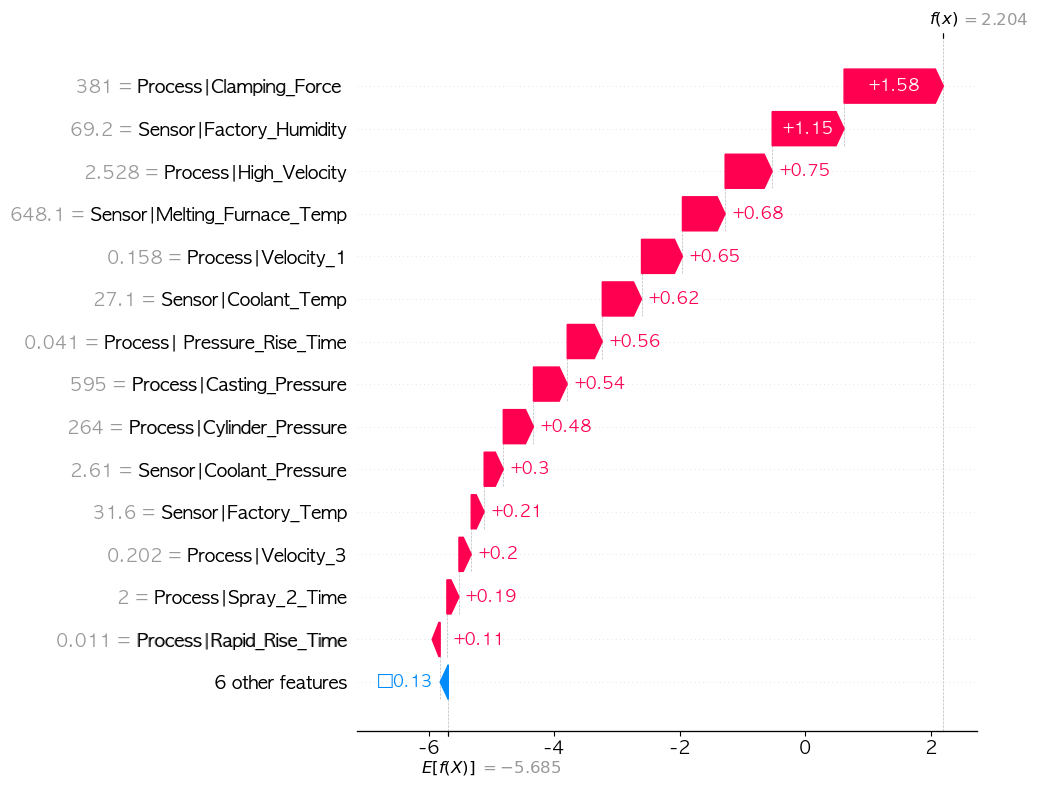


[LightGBM Feature Importance Top5 – 전체 그룹]


,defect_group,rank_1,rank_2,rank_3,rank_4,rank_5
0,충전불량,Process|High_Velocity,Sensor|Melting_Furnace_Temp,Sensor|Factory_Humidity,Process|Velocity_3,Process|Velocity_1
1,기포/내부,Process|High_Velocity,Sensor|Melting_Furnace_Temp,Sensor|Factory_Humidity,Process|Velocity_3,Process|Velocity_1
2,표면손상,Process|High_Velocity,Sensor|Melting_Furnace_Temp,Sensor|Factory_Humidity,Process|Velocity_3,Sensor|Coolant_Pressure
3,기타,Process|High_Velocity,Sensor|Melting_Furnace_Temp,Sensor|Factory_Humidity,Process|Velocity_1,Sensor|Air_Pressure


In [21]:
# ── Waterfall: 샘플 1개 분해
ROW_IDX = 0   # 분석할 샘플 인덱스 (0~len(Xexp)-1)

base = explainer.expected_value
if isinstance(base,(list,np.ndarray)):
    base = base[1] if len(base)>1 else base[0]

exp = shap.Explanation(
    values       = sv[ROW_IDX],
    base_values  = base,
    data         = Xexp.iloc[ROW_IDX].values,
    feature_names= list(Xexp.columns)
)
shap.plots.waterfall(exp, max_display=15)

# ── 전체 그룹 Top5 요약
print("\n[LightGBM Feature Importance Top5 – 전체 그룹]")
fi_rows = []
for gname in lgbm_results:
    top5 = lgbm_results[gname]["top10"].head(5).index.tolist()
    fi_rows.append({"defect_group":gname,**{f"rank_{i+1}":f for i,f in enumerate(top5)}})
display(pd.DataFrame(fi_rows))


## 6. Decision Logic

| 단계 | 내용 |
|---|---|
| ① 진단 | LightGBM 불량 발생 확률 (%) |
| ② 추적 | SHAP Waterfall 기준 양성 기여 변수 Top N |
| ③ 비교 | 정상군 중앙값 대비 상대 편차 (%) |
| ④ 판정 | 편차 방향·크기 기반 위험/안전 |

In [23]:
def decision_logic(target_group: str, sample_idx: int = 0, top_n: int = 5) -> None:
    """LightGBM + SHAP 기반 불량 진단 4단계 리포트"""
    res  = lgbm_results[target_group]
    mdl  = res["model"]
    Xte  = res["X_test"]
    yte  = res["y_test"]
    ridx = min(sample_idx, len(Xte)-1)

    # ① 진단
    prob   = float(mdl.predict_proba(Xte.iloc[[ridx]])[0,1])
    label  = "불량" if prob >= THRESHOLD else "정상"
    actual = int(yte.iloc[ridx])

    print(f"{'='*58}")
    print(f"  [① 진단]  그룹: {target_group}  |  샘플 #{ridx}")
    print(f"  불량 발생 확률: {prob:.1%}  |  판정: {label}  |  실제: {'불량' if actual else '정상'}")

    # SHAP (로컬)
    _exp = shap.TreeExplainer(mdl)
    sv_l = _get_sv(_exp.shap_values(Xte.iloc[[ridx]]))[0]

    # ② 추적
    shap_df = pd.DataFrame({"feature":Xte.columns,"shap":sv_l})
    top_pos = (shap_df[shap_df["shap"]>0]
               .sort_values("shap",ascending=False)
               .head(top_n))

    # ③ 비교 기준: 정상군 중앙값
    y_full  = Y_group[target_group]
    ref_med = X[y_full==0].median()

    print(f"[② 추적 → ③ 비교 → ④ 판정]  상위 원인 변수 Top {top_n}")
    print(f"  {'순위':<4} {'변수':<35} {'기준값':>9} {'현재값':>9} {'편차':>9} {'판정':>6}")
    print("  " + "-"*75)
    for rank,(_, row) in enumerate(top_pos.iterrows(), 1):
        feat    = row["feature"]
        cur     = float(Xte.iloc[ridx][feat])
        ref     = float(ref_med[feat]) if feat in ref_med.index else np.nan
        dev     = (cur-ref)/ref*100 if ref and ref!=0 else 0.0
        risk    = "⚠ 위험" if abs(dev)>10 else "✔ 안전"
        label_f = feat.replace("Process|","").replace("Sensor|","").replace("_"," ")
        print(f"  {rank:<4} {label_f:<35} {ref:>9.3f} {cur:>9.3f} {dev:>+8.1f}% {risk:>6}")

    print(f"[기준] 정상군 중앙값 | [편차] (현재-기준)/기준×100 | |편차|>10% → 위험")


decision_logic("충전불량", sample_idx=0, top_n=5)


  [① 진단]  그룹: 충전불량  |  샘플 #0
  불량 발생 확률: 0.7%  |  판정: 정상  |  실제: 정상
[② 추적 → ③ 비교 → ④ 판정]  상위 원인 변수 Top 5
  순위   변수                                        기준값       현재값        편차     판정
  ---------------------------------------------------------------------------
  1    Spray 2 Time                            0.800     0.800     +0.0%   ✔ 안전
  2     Pressure Rise Time                     0.041     0.043     +4.9%   ✔ 안전
  3    Rapid Rise Time                         0.008     0.008     +0.0%   ✔ 안전
  4    Velocity 1                              0.144     0.144     +0.0%   ✔ 안전
  5    Coolant Temp                           26.800    26.500     -1.1%   ✔ 안전
[기준] 정상군 중앙값 | [편차] (현재-기준)/기준×100 | |편차|>10% → 위험


In [24]:
# 전체 그룹 일괄 실행
for g in Y_group.columns:
    print()
    decision_logic(g, sample_idx=0, top_n=3)



  [① 진단]  그룹: 충전불량  |  샘플 #0
  불량 발생 확률: 0.7%  |  판정: 정상  |  실제: 정상
[② 추적 → ③ 비교 → ④ 판정]  상위 원인 변수 Top 3
  순위   변수                                        기준값       현재값        편차     판정
  ---------------------------------------------------------------------------
  1    Spray 2 Time                            0.800     0.800     +0.0%   ✔ 안전
  2     Pressure Rise Time                     0.041     0.043     +4.9%   ✔ 안전
  3    Rapid Rise Time                         0.008     0.008     +0.0%   ✔ 안전
[기준] 정상군 중앙값 | [편차] (현재-기준)/기준×100 | |편차|>10% → 위험

  [① 진단]  그룹: 기포/내부  |  샘플 #0
  불량 발생 확률: 0.0%  |  판정: 정상  |  실제: 정상
[② 추적 → ③ 비교 → ④ 판정]  상위 원인 변수 Top 3
  순위   변수                                        기준값       현재값        편차     판정
  ---------------------------------------------------------------------------
  1    Velocity 3                              0.187     0.180     -3.7%   ✔ 안전
  2    Casting Pressure                     1037.000  1036.000     -0.1%   ✔ 안전
  3    Air Pressure 

## 7. Business Impact (추가)

> PPT의 비용 절감 효과 계산을 코드로 재현합니다.  
> FN 손실: ₩3,000 / 개 (불량을 정상으로 → 고객 클레임)  
> FP 손실: ₩20,000 / 개 (정상을 불량으로 → 불필요한 재검사)

model,LightGBM,RandomForest,XGBoost
defect_group,,,
기타,"966,000","838,000","647,000"
기포/내부,"557,000","1,027,000","2,736,000"
충전불량,"636,000","966,000","2,785,000"
표면손상,"668,000","905,000","2,638,000"


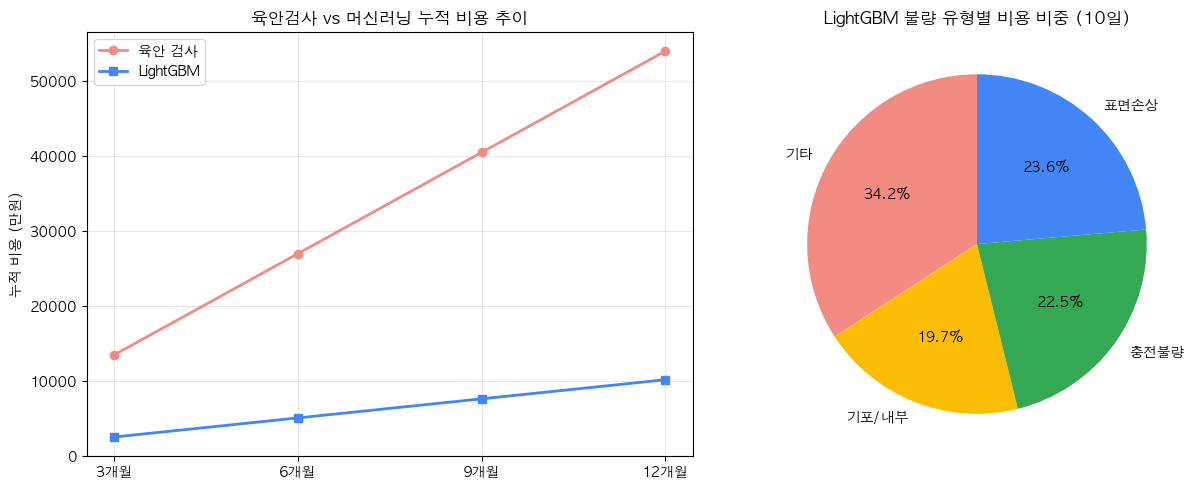

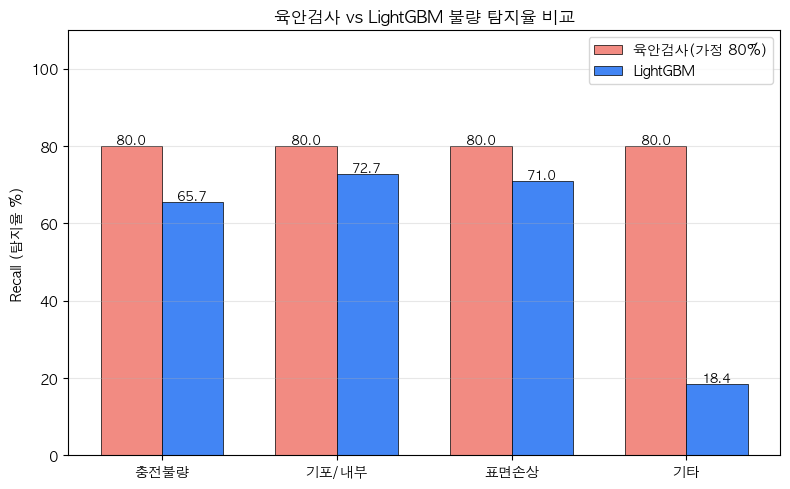


[연간 절감 추정액] 438,228,000원 (4.38억원) — 가정 기반, 실제 비용 확인 후 조정 필요


In [25]:
# ── 비용 설정 (PPT 수치 그대로)
COST_FN = 3_000    # 불량을 정상 판정 (FN): 고객 반품/클레임
COST_FP = 20_000   # 정상을 불량 판정 (FP): 재검사/폐기

# ── 모델별 10일 비용 계산 (일 500샷 가정)
DAILY_SHOTS = 500
DAYS = 10

cost_rows = []
for mname, rdict in [("RandomForest",rf_results),
                      ("XGBoost",    xgb_results),
                      ("LightGBM",   lgbm_results)]:
    for gname, d in rdict.items():
        cm = d["cm"]
        fp, fn = int(cm[0,1]), int(cm[1,0])
        total_test = cm.sum()
        # 테스트셋 비율로 실제 10일 규모로 환산
        fp_10d = int(fp/total_test * DAILY_SHOTS * DAYS)
        fn_10d = int(fn/total_test * DAILY_SHOTS * DAYS)
        cost = fp_10d*COST_FP + fn_10d*COST_FN
        cost_rows.append({"model":mname,"defect_group":gname,
                           "FP(10일)":fp_10d,"FN(10일)":fn_10d,"비용(원)":cost})

cost_df = pd.DataFrame(cost_rows)
cost_pivot = cost_df.pivot_table(index="defect_group",columns="model",
                                  values="비용(원)",aggfunc="sum")
display(cost_pivot.applymap(lambda x: f"{x:,.0f}"))

# ── 3개월 단위 누적 비용 추이 (시각화)
months = [3,6,9,12]
# 육안검사 기준: 탐지율 80% 가정, 일 2시간 × 인건비 기준 추정
manual_base_per_month = 45_000_000   # 월 4500만원 (가정)

lgbm_total = cost_df[cost_df["model"]=="LightGBM"]["비용(원)"].sum()  # 10일치
lgbm_per_month = lgbm_total * 3   # 월 비용 (10일 × 3)

fig, axes = plt.subplots(1,2,figsize=(13,5))

# 좌: 누적 비용 추이
manual_cum = [manual_base_per_month * m / 1e4 for m in months]
lgbm_cum   = [lgbm_per_month * m / 1e4 for m in months]
axes[0].plot(months, manual_cum, "o-", color="#f28b82", lw=2, label="육안 검사")
axes[0].plot(months, lgbm_cum,   "s-", color="#4285f4", lw=2, label="LightGBM")
axes[0].set_xticks(months); axes[0].set_xticklabels([f"{m}개월" for m in months])
axes[0].set_ylabel("누적 비용 (만원)")
axes[0].set_title("육안검사 vs 머신러닝 누적 비용 추이")
axes[0].legend(); axes[0].grid(alpha=0.3)

# 우: 그룹별 LightGBM 비용 분포
grp_cost = cost_df[cost_df["model"]=="LightGBM"].groupby("defect_group")["비용(원)"].sum()
colors_pie = ["#f28b82","#fbbc04","#34a853","#4285f4"]
axes[1].pie(grp_cost.values, labels=grp_cost.index, autopct="%1.1f%%",
             colors=colors_pie, startangle=90)
axes[1].set_title("LightGBM 불량 유형별 비용 비중 (10일)")

plt.tight_layout(); plt.show()

# ── 육안검사 vs 머신러닝 성능 비교
# (탐지율 = Recall 기준, 육안검사는 업계 평균 80% 가정)
fig, ax = plt.subplots(figsize=(8,5))
groups  = list(Y_group.columns)
manual_recall  = [0.80]*len(groups)   # 육안검사 가정
lgbm_recall    = [lgbm_results[g]["recall"] for g in groups]
x = np.arange(len(groups)); w = 0.35
b1 = ax.bar(x-w/2, [v*100 for v in manual_recall], w,
            label="육안검사(가정 80%)", color="#f28b82", edgecolor="black",lw=0.5)
b2 = ax.bar(x+w/2, [v*100 for v in lgbm_recall],   w,
            label="LightGBM", color="#4285f4", edgecolor="black",lw=0.5)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{bar.get_height():.1f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel("Recall (탐지율 %)"); ax.set_ylim(0,110)
ax.set_title("육안검사 vs LightGBM 불량 탐지율 비교")
ax.legend(); ax.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()

total_saving = manual_base_per_month*12 - lgbm_per_month*12
print(f"\n[연간 절감 추정액] {total_saving:,.0f}원 "
      f"({total_saving/1e8:.2f}억원) — 가정 기반, 실제 비용 확인 후 조정 필요")
